# Evaluation

In [1]:
import numpy as np
import torch

device = torch.device("cpu")

### Exploratory Data Analysis

In [2]:
from core.plotting import load_breath_pattern, load_cir, plot_measurements, plot_region_comparison, plot_interparticipant_variability, plot_correlation, plot_cir

In [3]:
# load data
CLASSES  = ["bradypnea", "eupnea", "tachypnea"]
t=np.linspace(0, 70, 300)
breath_pattern = load_breath_pattern(classes=CLASSES, dataset_dir="./dataset")
print(f"Total trials:\t\t\t{len(breath_pattern)},\nClasses:\t\t\t{breath_pattern["class"].unique()},\nParticipants:\t\t\t{breath_pattern["participant"].unique()}")

records = breath_pattern.to_dict("records")
durations = np.array([row["time"][-1] - row["time"][0] for row in records])
n_samples = np.array([len(row["time"]) for row in records])
all_intervals = np.concatenate([np.diff(row["time"]) for row in records])
print(f"Samples per trial:\t\tmin={n_samples.min()}, max={n_samples.max()}, mean={n_samples.mean():.1f}")
print(f"Trial duration (s):\t\tmin={durations.min():.1f}, max={durations.max():.1f}, mean={durations.mean():.1f}")
print(f"Sampling interval (ms):\t\tmean={all_intervals.mean()*1000:.0f}, std={all_intervals.std()*1000:.0f}")
print(f"Effective sampling rate:\t~{1/all_intervals.mean():.3f} Hz")
print(f"Nyquist limit:\t\t\t{0.5/all_intervals.mean():.2f} Hz -> max detectable breath rate: {0.5/all_intervals.mean()*60:.0f} BPM")

Total trials:			645,
Classes:			['bradypnea' 'eupnea' 'tachypnea'],
Participants:			['a' 'p' 's']
Samples per trial:		min=36, max=36, mean=36.0
Trial duration (s):		min=70.1, max=70.2, mean=70.2
Sampling interval (ms):		mean=2004, std=1
Effective sampling rate:	~0.499 Hz
Nyquist limit:			0.25 Hz -> max detectable breath rate: 15 BPM


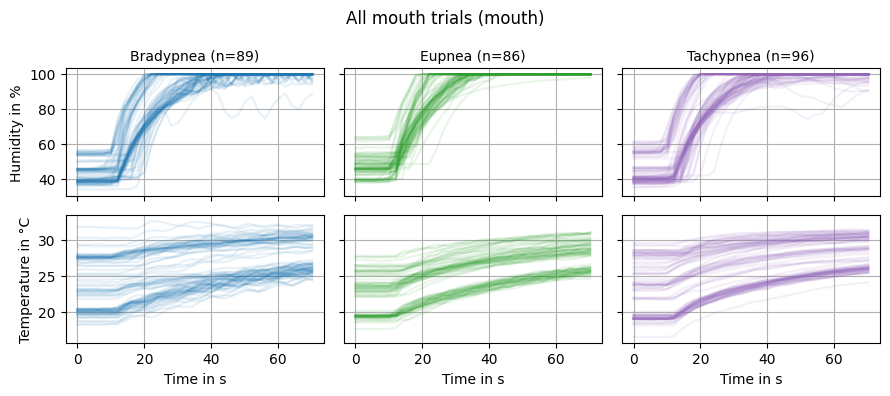

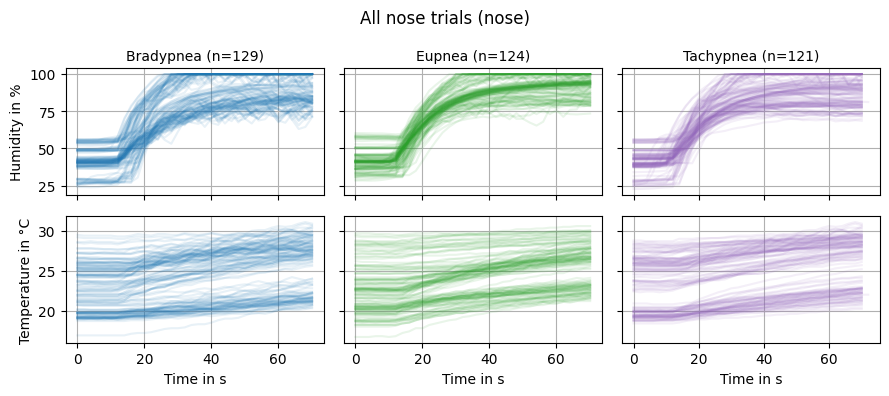

In [4]:
plot_measurements(breath_pattern, region="mouth")
plot_measurements(breath_pattern, region="nose")

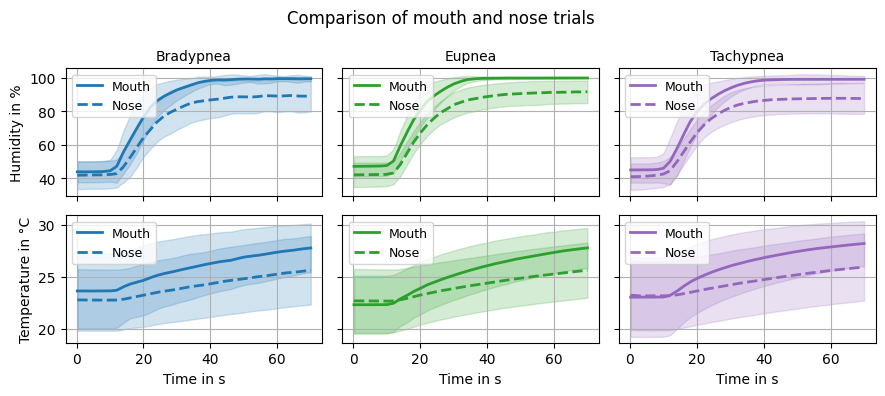

In [5]:
plot_region_comparison(breath_pattern, t)

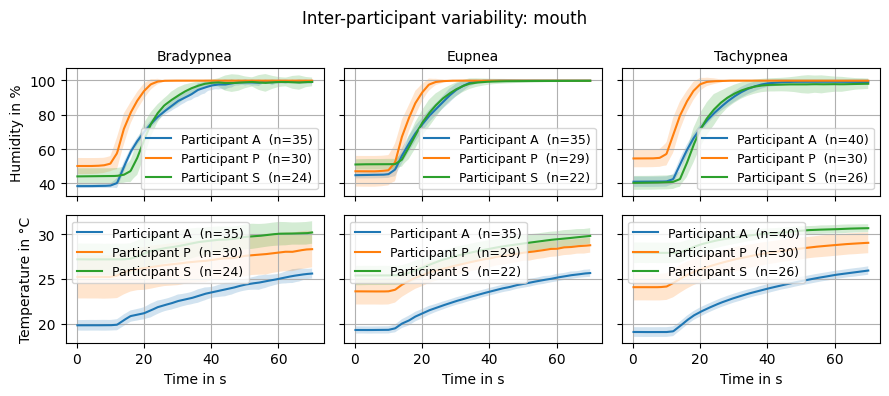

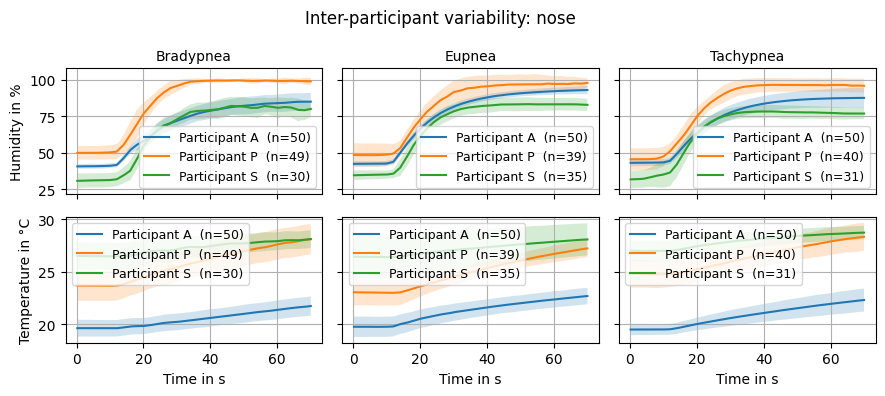

In [6]:
plot_interparticipant_variability(breath_pattern, t, region="mouth")
plot_interparticipant_variability(breath_pattern, t, region="nose")

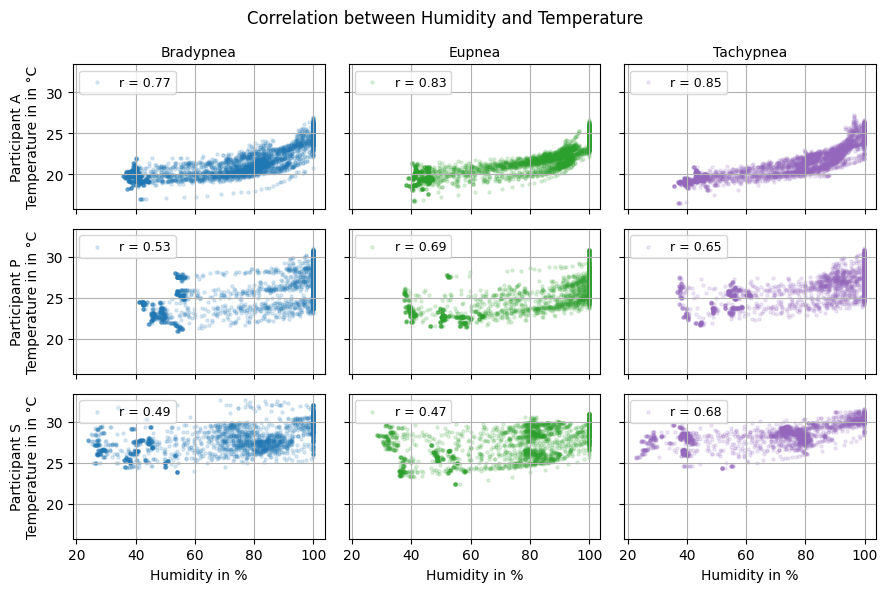

In [7]:
plot_correlation(breath_pattern)

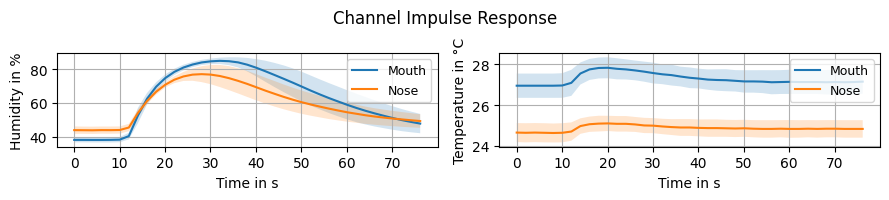

In [8]:
cir = load_cir(dataset_dir="./dataset")
plot_cir(cir)

### Train-Real-Test-Real

In [1]:
from core.plotting import load_trtr_features, plot_trtr_ablation, plot_trtr_feature_count, plot_trtr_feature_stability, plot_trtr_channel_contribution

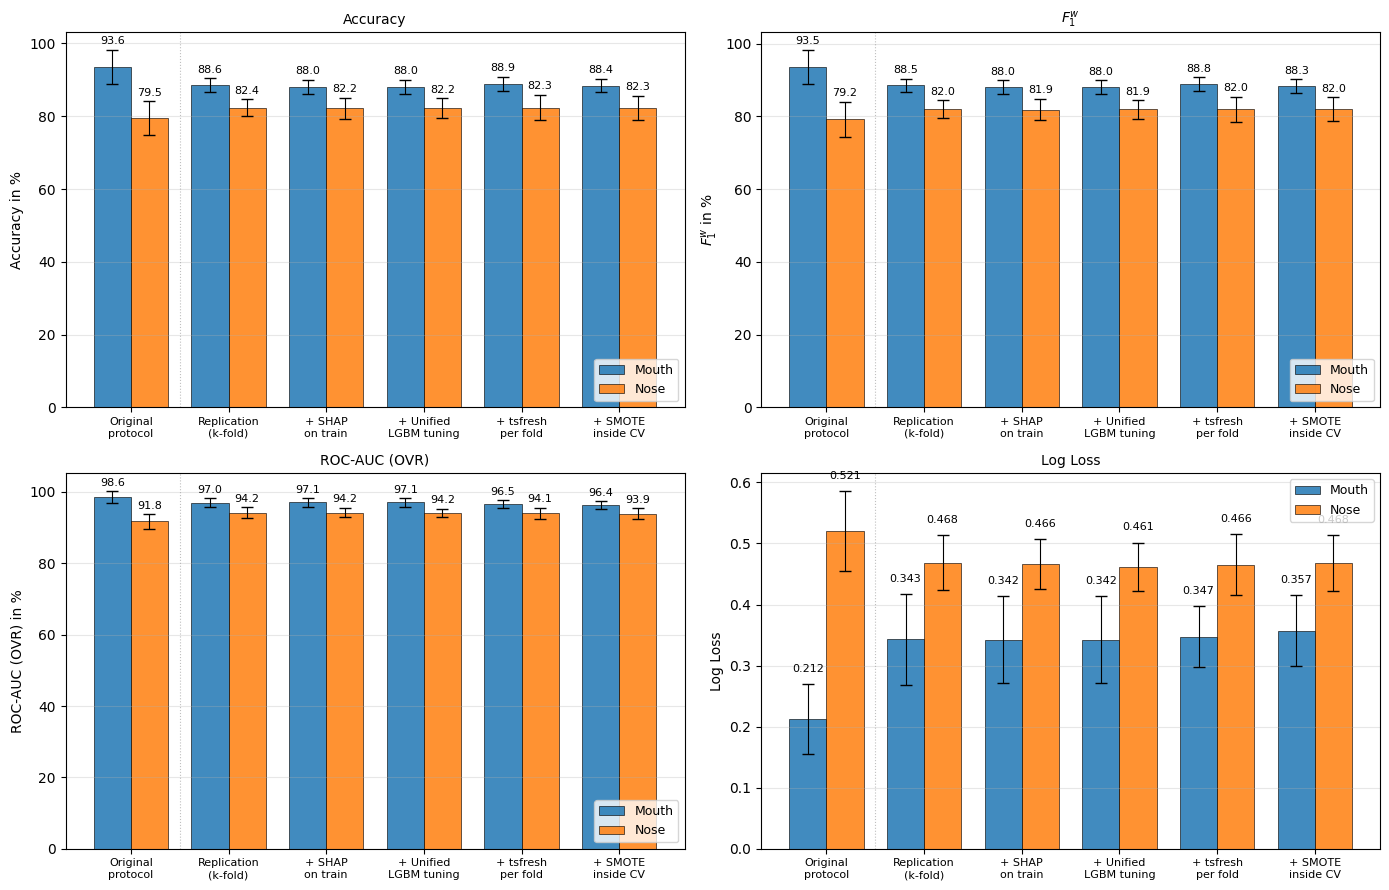

In [2]:
plot_trtr_ablation()

In [3]:
feature_counts = load_trtr_features()

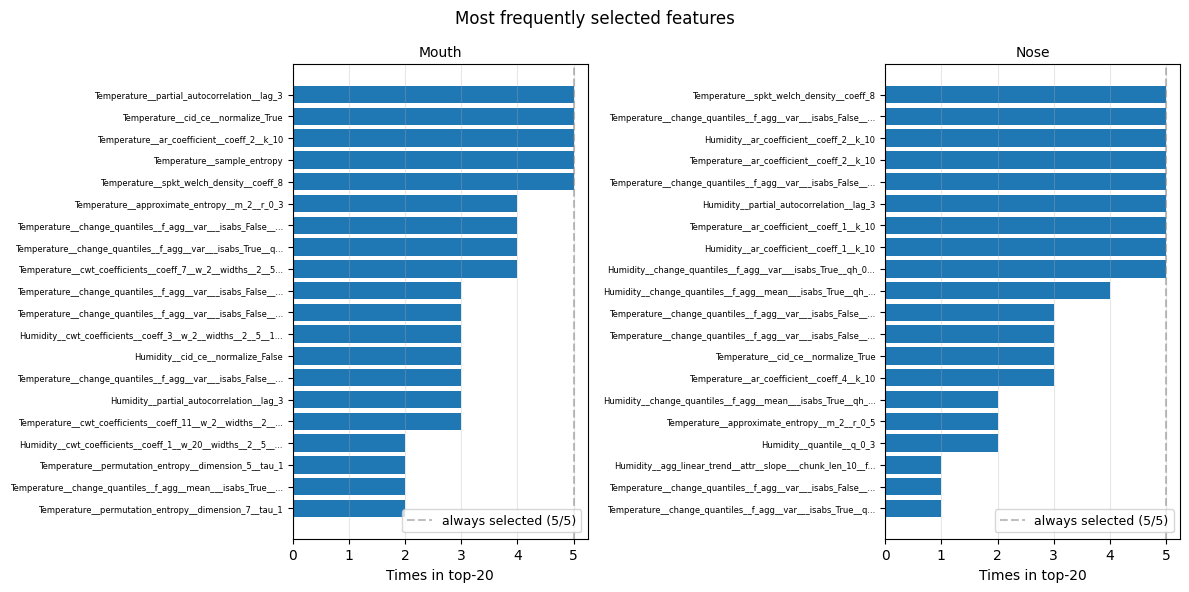

In [4]:
plot_trtr_feature_count(feature_counts)

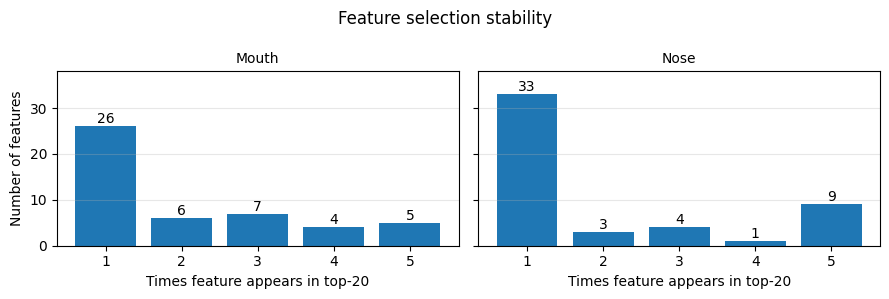

In [5]:
plot_trtr_feature_stability(feature_counts)

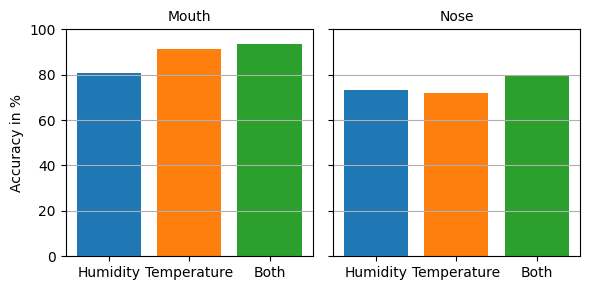

In [2]:
plot_trtr_channel_contribution()

### Variational Autoencoder

In [14]:
from core.plotting import load_vaes, plot_vae_training, plot_vae_active_dims_training, plot_vae_active_dims_final, plot_vae_tSNE

In [15]:
models, datasets = load_vaes(device)

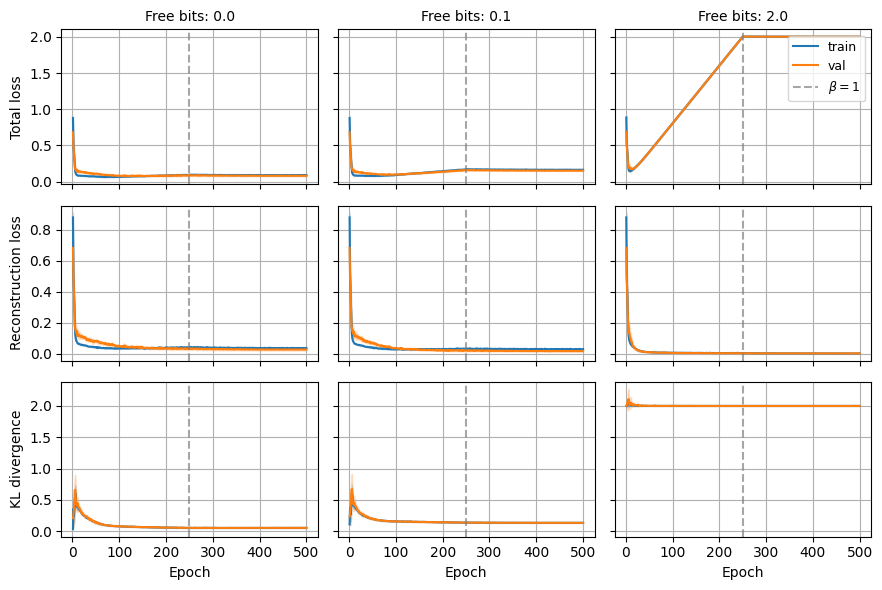

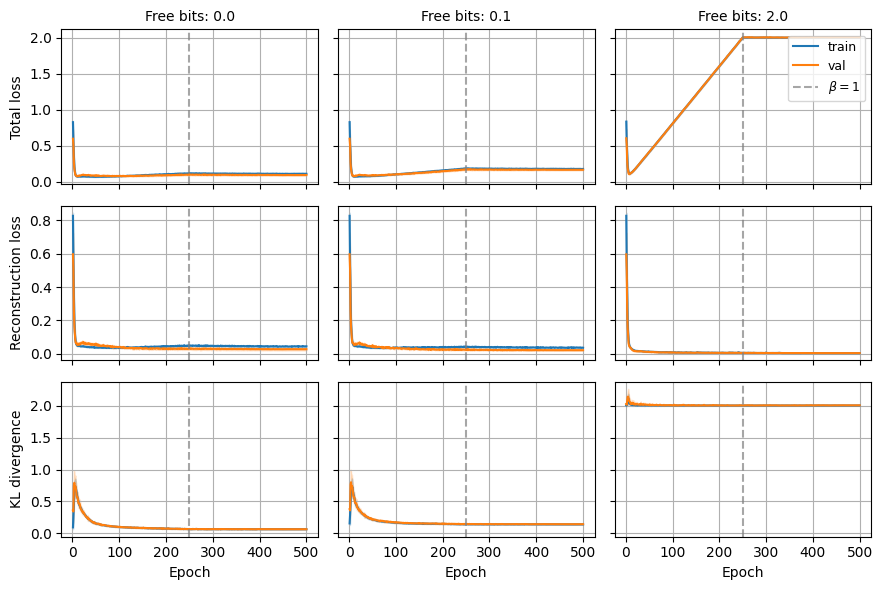

In [ ]:
plot_vae_training("mouth")
plot_vae_training("nose")

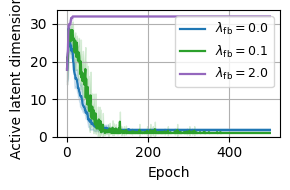

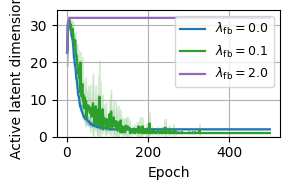

In [ ]:
plot_vae_active_dims_training("mouth")
plot_vae_active_dims_training("nose")

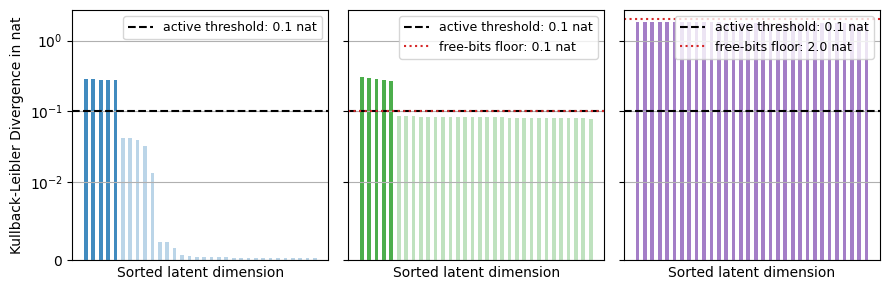

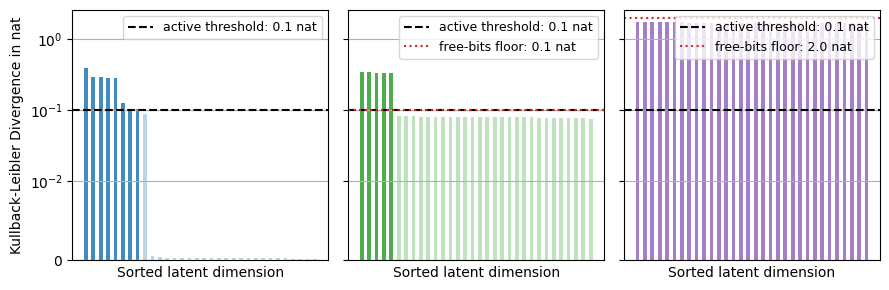

In [18]:
plot_vae_active_dims_final(models, datasets, region="mouth")
plot_vae_active_dims_final(models, datasets, region="nose")

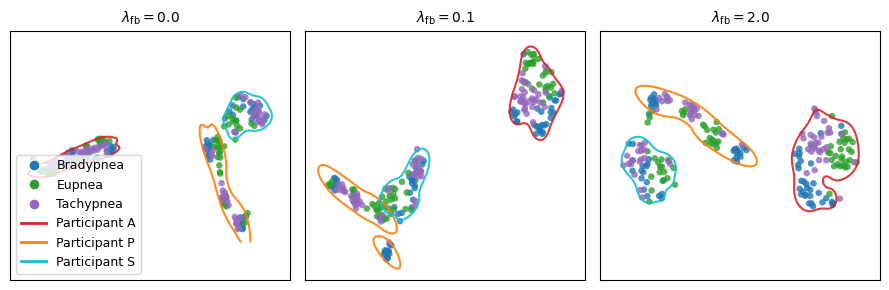

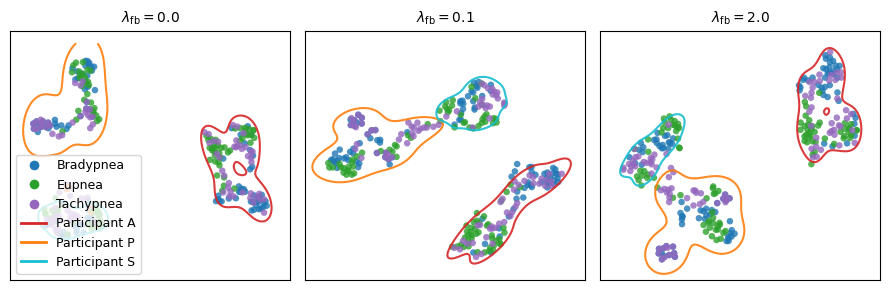

In [19]:
plot_vae_tSNE(models, datasets, region="mouth")
plot_vae_tSNE(models, datasets, region="nose")

### Conditional Variational Autoencoder

In [20]:
from core.plotting import load_cvae_ablation_data, load_cvaes, plot_cvae_architecture_ablation, plot_cvae_architecture_dynamics, plot_cvae_beta_sweep, plot_cvae_beta_active_dims, plot_cvae_tSNE, plot_cvae_lag, plot_cvae_summary, plot_cvae_jittering

In [21]:
arch_summary, arch_history, dyn_summary, dyn_history = load_cvae_ablation_data()

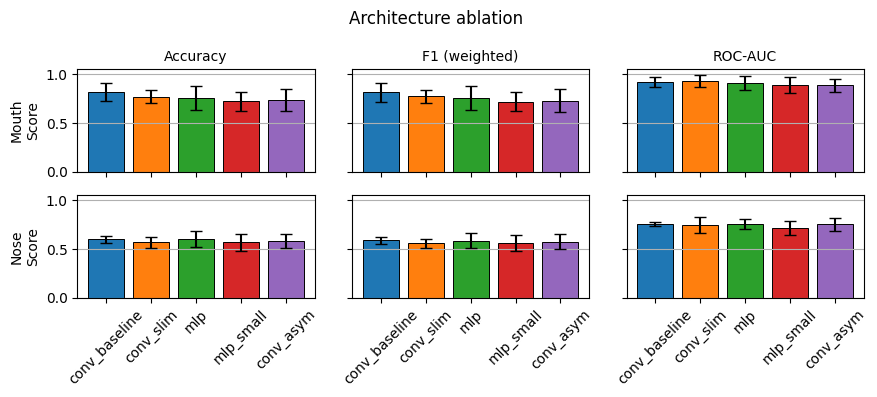

In [22]:
plot_cvae_architecture_ablation(arch_summary)

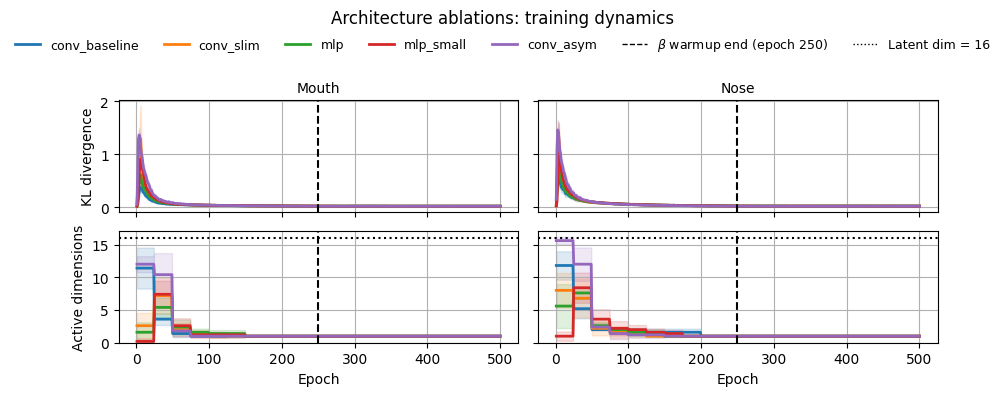

In [23]:
plot_cvae_architecture_dynamics(arch_history)

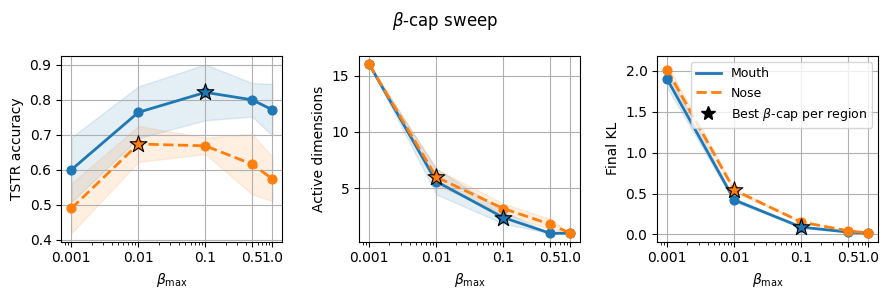

In [24]:
plot_cvae_beta_sweep(dyn_summary)

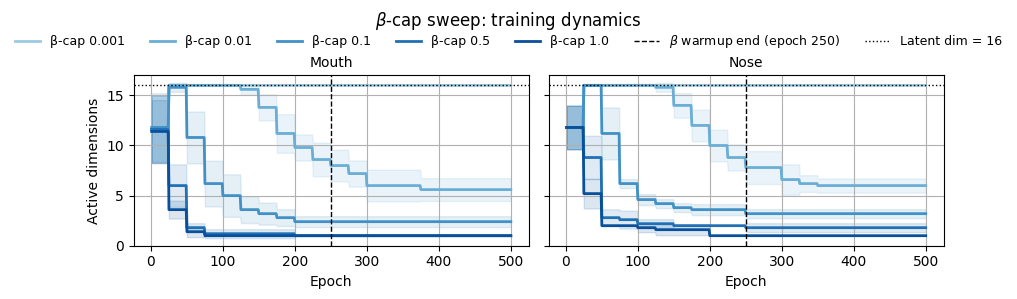

In [25]:
plot_cvae_beta_active_dims(dyn_history)

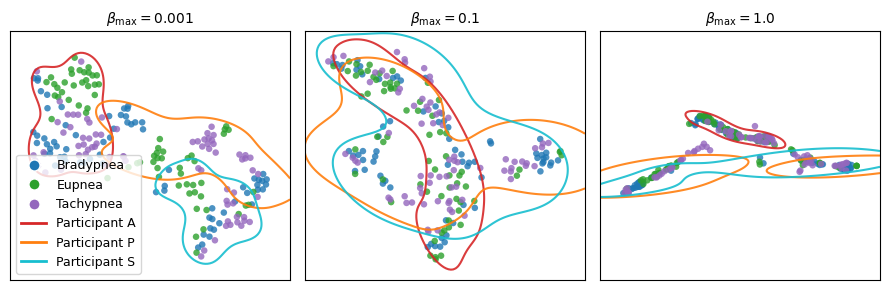

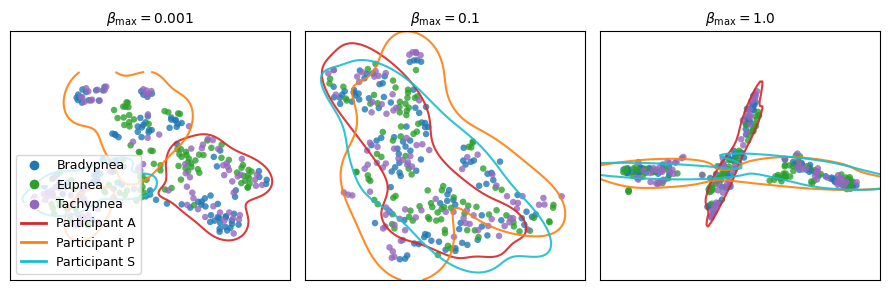

In [26]:
models, datasets = load_cvaes(device)
plot_cvae_tSNE(models, datasets, region="mouth")
plot_cvae_tSNE(models, datasets, region="nose")

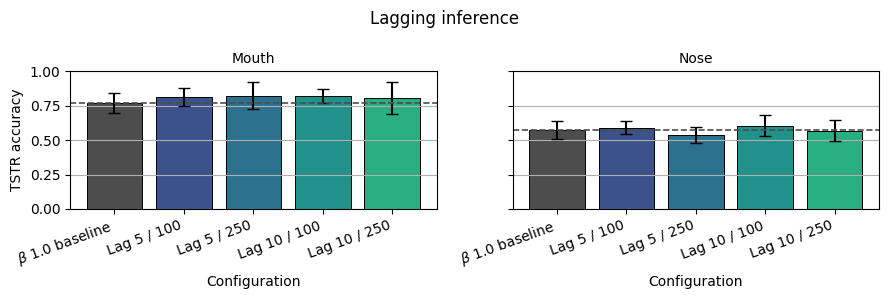

In [27]:
plot_cvae_lag(dyn_summary)

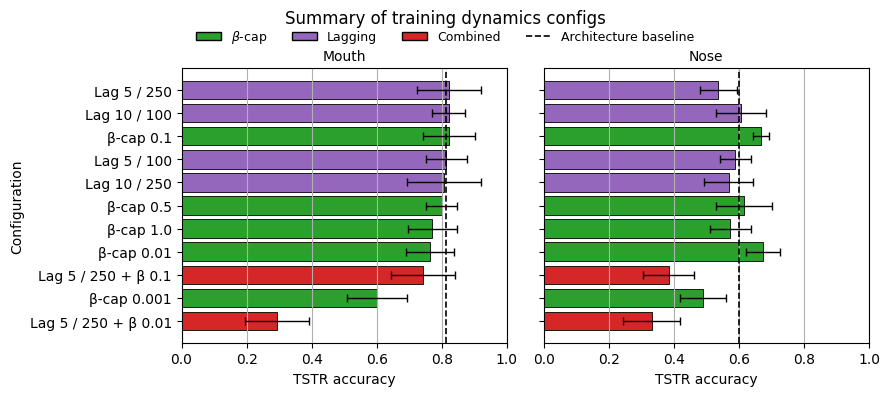

In [28]:
plot_cvae_summary(dyn_summary, arch_summary)

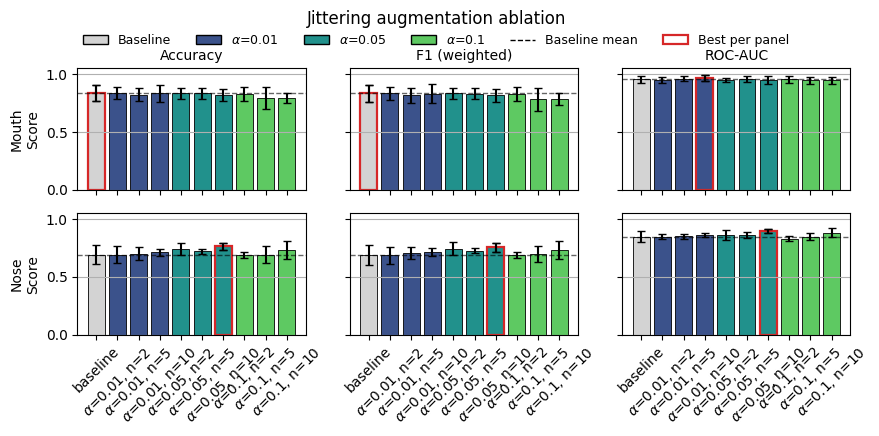

In [29]:
plot_cvae_jittering()

### Physics-Informed Conditional Variational Autoencoder